# LangGraph 测试Notebook
---
目标：验证 LangGraph `StateGraph` 基础流转，建立 `GlobalState` 定义与各层节点骨架。

该Notebook是另外一个的改写，只保留真正实现了的逻辑。

In [1]:
# ── 依赖安装 ──────────────────────────────────────────────────────────────────
%pip install -q python-dotenv
%pip install -qU langchain-core langchain-ollama
%pip install -qU langgraph
%pip install -qU langchain-anthropic

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 1.2.10 requires langgraph<1.1.0,>=1.0.8, but you have langgraph 1.1.3 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

# ── 导入与环境初始化 ───────────────────────────────────────────────────────────
import os,sys
# Jupyter notebooks don't define __file__, so locate the project root by
# searching upward for CLAUDE.md (the project marker file).
def _find_project_root(marker: str = "CLAUDE.md") -> str:
    path = os.path.abspath("")
    for _ in range(6):
        if os.path.exists(os.path.join(path, marker)):
            return path
        path = os.path.dirname(path)
    raise RuntimeError(f"Project root not found (searched for '{marker}')")

_root = _find_project_root()
if _root not in sys.path:
    sys.path.insert(0, _root)
print("Project root:", _root)
import getpass
import logging
from dotenv import load_dotenv

from langchain_ollama import ChatOllama
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_anthropic import ChatAnthropic

from langgraph.graph import StateGraph, START, END

from langchain.agents import create_agent
from pydantic import BaseModel, Field
from SkiLib.metatools.informative import get_tools as get_info_tools
from SkiLib.registry import SkillRegistry

# 从项目根目录 .env 加载 API Key 与追踪配置
load_dotenv()

# LangSmith 追踪（可选 — 在 .env 中设置 LANGSMITH_TRACING=true 启用）
if os.getenv("LANGSMITH_TRACING", "false").lower() == "true":
    if not os.getenv("LANGSMITH_API_KEY"):
        os.environ["LANGSMITH_API_KEY"] = getpass.getpass("Enter LangSmith API Key: ")
    if not os.getenv("LANGSMITH_PROJECT"):
        os.environ["LANGSMITH_PROJECT"] = getpass.getpass("Enter LangSmith Project name: ")

logging.basicConfig(level=logging.ERROR, force=True)
print("Environment loaded. LangSmith tracing:", os.getenv("LANGSMITH_TRACING", "false"))

Project root: c:\Users\fengy\RoboSkiAgent


c:\Users\fengy\RoboSkiAgent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment loaded. LangSmith tracing: true


In [3]:
LLM_TYPE = "claude"  # 可选 "claude" 或 "ollama"（本地）
# ── LLM 配置 ──────────────────────────────────────────────────────────────────
# 使用本地 Ollama 时修改 OLLAMA_MODEL_ID 切换模型
OLLAMA_MODEL_ID = os.getenv("OLLAMA_MODEL_ID", "qwen3:latest")
OLLAMA_BASE_URL = os.getenv("OLLAMA_BASE_URL", "http://localhost:11434")

if LLM_TYPE == "claude":
    llm = ChatAnthropic(
        model="claude-sonnet-4-6"
    )
else:
    llm = ChatOllama(
        model=OLLAMA_MODEL_ID,
        base_url=OLLAMA_BASE_URL,
        temperature=0,
    )

# 快速连通性检查
try:
    _ping = llm.invoke("Reply with one word: ready")
    print("LLM reachable:", _ping.content.strip()[:80])
except Exception as e:
    print(f"[WARN] LLM not reachable — nodes using llm will fail. ({e})")

LLM reachable: ready


## GlobalState
与 `CLAUDE.md` 中 `GlobalState` 规范保持一致。  
`robot_state` 此处用 `dict` 代替，生产版本从 `SkiLib.base` 导入 `RobotState`。

In [4]:
# ── GlobalState 定义 ──────────────────────────────────────────────────────────
from typing import TypedDict, Annotated, Optional, Literal
import operator
from SkiLib.base import SkillResult


class GlobalState(TypedDict):
    # Layer-1：规划层输出
    todo_list: list[dict]           # [{task_id, type, skill/description, params}, ...]

    # Layer-2：执行上下文
    current_task: dict              # 执行槽：{} = 空闲，{...} = 执行中或失败保留

    # 机器人运行时快照（此处用 dict 代替，生产类型：SkiLib.base.RobotState）
    robot_state: dict

    # 控制标志
    halt_flag: bool                 # True = 所有 R-skill 执行被锁定
    halt_reason: Optional[str]      # "TASK_FAILURE" | "MANUAL_TASK" | None

    # Executor 写入；含 needs_hitl 字段供 Context Flush 决策
    last_result: Optional[SkillResult]

    # 内部路由字段：HumanIntervention的结果, = "complete" | "abort"
    intervention_action: Optional[str]

    # 解耦出的单独在HITL结束后的action， = "retry" | "next_task" | "replan" | "abort"
    hitl_command: Optional[str]

    # 审计日志，由 Context Flush 写入；Annotated list 避免键覆盖
    execution_log: Annotated[list[str], operator.add]

    # LangGraph 消息总线
    messages: Annotated[list[BaseMessage], operator.add]


print("GlobalState keys:", list(GlobalState.__annotations__.keys()))


GlobalState keys: ['todo_list', 'current_task', 'robot_state', 'halt_flag', 'halt_reason', 'last_result', 'intervention_action', 'hitl_command', 'execution_log', 'messages']


In [5]:
# ── 节点：Supervisor（新版，create_agent, create_react_agent已经废弃）────────────────────────────────
from langchain.agents import create_agent
from pydantic import BaseModel, Field
from SkiLib.metatools.informative import get_tools as get_info_tools
from SkiLib.registry import SkillRegistry


# ── SupervisorOutput Schema ───────────────────────────────────────────────────
# available_skills 不在此 schema 中 — 由代码从 SkillRegistry 注入，LLM 不填写。
class SupervisorOutput(BaseModel):
    """Fact sheet produced after knowledge saturation. Symbol-only, no coordinates."""
    task_intent_original: str = Field(description="Verbatim user instruction")
    
    task_intent: str = Field(
        description="Rewritten instruction using exact RoboDK symbol names"
    )
    
    scene: dict = Field(
        description="Keys: targets (list[str]), objects (list[str]), tools (list[str])"
    )
    
    # available_skills: This will be injected by code, not filled by LLM. Keys: skill name, docstring.
    
    extra_info: str = Field(
        default="",
        description="Unresolvable ambiguities or free-text observations"
    )


def _get_available_skills() -> dict:
    """Pure-code: read skill signatures from SkillRegistry. No LLM involved."""
    registry = SkillRegistry.instance()
    if not registry:
        return {}
    return {
        name: registry.get_skill(name).execute.__doc__ or ""
        for name in registry.list_skills()
    }


# ── System Prompt ─────────────────────────────────────────────────────────────
def _build_supervisor_prompt() -> str:
    skills_text = "\n".join(
        f"  - {name}: {doc.strip()}"
        for name, doc in _get_available_skills().items()
    ) or "  (none registered)"

    return f"""\
You are the Supervisor agent in an industrial robot assembly system.

Your ONLY job: gather scene facts and produce a structured SupervisorOutput summary.
Do NOT plan tasks, choose skills, or compute coordinates.

Rules:
- Call tools to query the RoboDK scene until you have enough information.
- Rewrite the instruction in `task_intent` using exact RoboDK symbol names 
and exact skill names (e.g. "Part_A_1", not "part A", "PickAndPlace" (A skill that exists) instead of "Pick and Place").
- All `scene` fields must use exact names returned by query tools — no invented names.
- Never include coordinates, joint angles, or numeric poses anywhere in your output.
- Record unresolvable ambiguities in `extra_info` instead of guessing.

Available skills (for your reference only — do not invent new ones):
{skills_text}
"""


# ── Lazy singleton ────────────────────────────────────────────────────────────
_supervisor_agent = None

def _get_supervisor_agent():
    global _supervisor_agent
    if _supervisor_agent is None:
        _supervisor_agent = create_agent(
            model=llm,
            tools=get_info_tools(),
            response_format=SupervisorOutput,
            system_prompt=_build_supervisor_prompt(),
        )
        print("[supervisor] Agent built. Skills:", list(_get_available_skills().keys()))
    return _supervisor_agent


# ── Node function ─────────────────────────────────────────────────────────────
def supervisor(state: GlobalState) -> dict:
    result = _get_supervisor_agent().invoke({"messages": state["messages"]})

    summary: SupervisorOutput | None = result.get("structured_response")
    if summary is None:
        #重新思考fallback逻辑：跳出？
        raw = state["messages"][-1].content
        raw_str = raw if isinstance(raw, str) else str(raw)
        summary = SupervisorOutput(
            task_intent_original=raw_str,
            task_intent=raw_str,
            scene={},
            extra_info="response_format unsupported — stub fallback",
        )


    output = summary.model_dump()
    # Inject available_skills from registry (pure code, not LLM output)
    output["available_skills"] = _get_available_skills()

    return {"messages": [AIMessage(content=str(output))]}


print("Supervisor cell loaded.")

Supervisor cell loaded.


In [6]:
# ── Supervisor 单元测试 ───────────────────────────────────────────────────────
# 前提：RoboDK 已启动
from SkiLib.robotcontext import RobotContext
from SkiLib.registry import SkillRegistry
import json
# 1. 拉起 RoboDK API
context = RobotContext()
RDK    = context.RDK
robot  = context.robot
skill_registry = SkillRegistry.instance()
print("[init] RobotContext OK, skills:", skill_registry.list_skills())

# 2. 重置 supervisor 单例（使其用已初始化的 SkillRegistry 重建）
_supervisor_agent = None

# 3. 构造最小初始状态
_test_state = {
    "messages":      [HumanMessage(content="把 Part_A_1 放到 Place Part A")],
    "todo_list":     [], "current_task": {}, "robot_state": {},
    "halt_flag":     False, "halt_reason": None,
    "last_result":   None, "_hi_action":  None, "execution_log": [],
}

# 4. 运行
print("\n[test] Running supervisor...")
_updates = supervisor(_test_state)

# 5. 解析输出
_out = _updates["messages"][-1].content

2026-03-26 16:49:43,097 [INFO] SkiLib.registry — SkillRegistry: registered 'DummySkill'
2026-03-26 16:49:43,099 [INFO] SkiLib.registry — SkillRegistry: registered 'PickAndPlace'


[PrimitiveRegistry] Registered: Grasp
[PrimitiveRegistry] Registered: Release
[PrimitiveRegistry] Registered: MoveJ
[PrimitiveRegistry] Registered: MoveL
[DummySkill] __init__ called. Received primitives: ['Grasp', 'Release', 'MoveJ', 'MoveL']
[init] RobotContext OK, skills: ['DummySkill', 'PickAndPlace']

[test] Running supervisor...
[supervisor] Agent built. Skills: ['DummySkill', 'PickAndPlace']


In [7]:
_out

'{\'task_intent_original\': \'把 Part_A_1 放到 Place Part A\', \'task_intent\': \'使用 PickAndPlace 技能，将工件 Part_A_1 从 Pick Part A（接近点：App Pick Part A）拾取，放置到 Place Part A（接近点：App Place Part A）\', \'scene\': {\'targets\': [\'Pick Part A New\', \'Home A\', \'Place Part A\', \'App Place Part A \', \'App Pick Part A\', \'Pick Part A\', \'Pick Part B\', \'App Pick Part B\', \'App Place Part B\', \'Place Part B\', \'Home B\', \'Pick Part C\', \'App Pick Part C\', \'Place Part C\', \'App Place Part C\', \'Home C\', \'Target 6\'], \'objects\': [\'Base Cylinder\', \'New Table Actual\', \'New Table Actual-22\', \'New Table Actual-21\', \'New Table Actual-20\', \'New Table Actual-43\', \'New Table Actual-44\', \'New Table Actual-45\', \'New Table Actual-40\', \'New Table Actual-52\', \'New Table Actual-53\', \'Part_A_1\', \'Part_A_2\', \'Part_B_1\', \'Part_B_2\', \'Part_C_1\', \'Part_C_2\'], \'tools\': [\'Gripper Extension\']}, \'extra_info\': \'夹爪当前未抓取任何工件（grasped: []），可直接执行拾取动作。Place Part A 目标名末尾含空格（

In [8]:
#测试工具生成
skill_registry.get_tools()

[StructuredTool(name='DummySkill_check', description='Check that the dummy skill is reachable. message is echoed back in data.', args_schema=<class 'langchain_core.utils.pydantic.DummySkill_check'>, func=<function DummySkill.check at 0x00000294363967A0>),
 StructuredTool(name='DummySkill_try_execute', description='Run check then execute. Aborts on check failure.', args_schema=<class 'langchain_core.utils.pydantic.DummySkill_try_execute'>, func=<function DummySkill.try_execute at 0x0000029436395120>),
 StructuredTool(name='PickAndPlace_check', description='Pre-flight feasibility check.\n\nArgs:\n    item:            RoboDK name of the workpiece to grasp/release.\n    pick_approach:   Target name for the approach/depart point near pick.\n    pick_target:     Target name for the linear-move precise grasp point.\n    place_approach:  Target name for the transit destination / depart point near place.\n    place_target:    Target name for the linear-move precise place point.\n    transit_mot

In [9]:
# ── 节点：Planner（工具调用版）────────────────────────────────────────────────
from pydantic import BaseModel, Field
from typing import Literal, Annotated, Union
from langchain_core.tools import StructuredTool
from langchain.agents import create_agent


# ── Task models（供下游 Dispatcher/Executor 读取）─────────────────────────────
class AutoTask(BaseModel):
    task_id: str
    type: Literal["auto"] = "auto"
    skill: str
    params: dict

class ManualTask(BaseModel):
    task_id: str
    type: Literal["manual"] = "manual"
    description: str

Task = Annotated[Union[AutoTask, ManualTask], Field(discriminator="type")]

class PlannerOutput(BaseModel):
    todo_list: list[Task]


# ── 动态工具生成 ───────────────────────────────────────────────────────────────
def _make_planner_tools(registry) -> tuple[list[StructuredTool], list[dict]]:
    """
    为每个 Skill 生成 add_<SkillName>_task 工具，直接复用 try_execute 的 args_schema。
    task_id 由代码自动追加（f"t{n}"），LLM 只需填写 skill 参数。
    """
    plan: list[dict] = []
    tools: list[StructuredTool] = []

    for skill_name in (registry.list_skills() if registry else []):
        skill = registry.get_skill(skill_name)
        try_exec = next(
            (t for t in skill.as_tools() if t.name.endswith("_try_execute")), None
        )  # only use try_execute for args_schema, ignore check
        if try_exec is None or try_exec.args_schema is None:
            continue

        # Generate a function shell for tool calling.
        def _create_task_adder(sname: str):
            def _add_task(**kwargs) -> str:
                task_id = f"t{len(plan) + 1}"
                plan.append({"task_id": task_id, "type": "auto", "skill": sname, "params": kwargs})
                return f"Task {task_id} ({sname}) added. Plan so far: {len(plan)} task(s)."
            return _add_task

        tools.append(StructuredTool(
            name=f"add_{skill_name}_task",
            description=f"Add a {skill_name} task. " + (try_exec.description or "").splitlines()[0],
            func=_create_task_adder(skill_name),
            args_schema=try_exec.args_schema,  # Reuse try_execute's args_schema for LLM input validation
        ))

    # Manual task 工具
    class AddManualTaskSchema(BaseModel):
        description: str = Field(description="What the human operator needs to do")

    def _add_manual(description: str) -> str:
        task_id = f"t{len(plan) + 1}"
        plan.append({"task_id": task_id, "type": "manual", "description": description})
        return f"Manual task {task_id} added."

    tools.append(StructuredTool.from_function(
        func=_add_manual,
        name="add_manual_task",
        description="Add a manual human-intervention step to the plan.",
        args_schema=AddManualTaskSchema,
    ))

    return tools, plan


_PLANNER_SYSTEM_PROMPT = """\
You are the planner of a symbolic robot assembly system.
Build a task plan by calling the provided tools — one call per task, in order.

Rules:
- Before each plan, add a manual task to let human operator check the whole plan. 
- Use ONLY exact symbol names from the scene in the user message — never invent names.
- Fill ALL required parameters (those without a default in the tool signature).
- Use add_manual_task when a step cannot be done by any provided tool.
- When done, stop calling tools. Do not output any JSON yourself.
"""


# ── Node function ─────────────────────────────────────────────────────────────
def planner(state: GlobalState) -> dict:
    print("[planner] Building plan via tool calls...")
    registry = SkillRegistry.instance()
    tools, plan = _make_planner_tools(registry)

    agent = create_agent(model=llm, tools=tools, system_prompt=_PLANNER_SYSTEM_PROMPT)

    # Supervisor 输出是 AIMessage — 重包成 HumanMessage，
    # 避免 Anthropic tool-use 模式下末尾 assistant 消息被拒。
    sup_content = state["messages"][-1].content
    agent.invoke({"messages": [HumanMessage(content=sup_content)]})

    manual_count = sum(1 for t in plan if t["type"] == "manual")
    print(f"[planner] Done: {len(plan)} tasks ({manual_count} manual)")

    return {
        "todo_list": plan,
        "messages": [AIMessage(content=f"[Planner] {len(plan)} tasks queued ({manual_count} manual)")],
    }


print("Planner cell loaded.")


Planner cell loaded.


In [10]:
# ── Planner 工具生成单元测试 ──────────────────────────────────────────────────
# 前提：RobotContext 已初始化（复用上方 cell 的 context）
from SkiLib.registry import SkillRegistry

registry = SkillRegistry.instance()
tools, _ = _make_planner_tools(registry)

print("Generated planner tools:")
for t in tools:
    schema = t.args_schema
    fields = list(schema.model_fields.keys()) if schema else None
    print(f"  {t.name}")
    print(f"    args_schema : {schema}")
    print(f"    fields      : {fields}")
    print()

auto_tools  = [t for t in tools if t.name != "add_manual_task"]
skill_names = registry.list_skills()

print(f"Registered skills : {skill_names}")
print(f"Auto tools found  : {[t.name for t in auto_tools]}")
print()

# 验证每个 skill 都有对应的 add_<SkillName>_task 工具
missing = [s for s in skill_names if f"add_{s}_task" not in [t.name for t in tools]]
if missing:
    print(f"[FAIL] Skills with no tool generated (args_schema likely None): {missing}")
else:
    print(f"[PASS] All {len(skill_names)} skill(s) have a corresponding add_<SkillName>_task tool.")

# 验证每个 auto tool 的 args_schema 非空
no_schema = [t.name for t in auto_tools if t.args_schema is None]
if no_schema:
    print(f"[FAIL] Tools with args_schema=None: {no_schema}")
else:
    print(f"[PASS] All auto tool(s) have a valid args_schema.")


Generated planner tools:
  add_DummySkill_task
    args_schema : <class 'langchain_core.utils.pydantic.DummySkill_try_execute'>
    fields      : ['message']

  add_PickAndPlace_task
    args_schema : <class 'langchain_core.utils.pydantic.PickAndPlace_try_execute'>
    fields      : ['item', 'pick_approach', 'pick_target', 'place_approach', 'place_target', 'transit_motion', 'initial_motion']

  add_manual_task
    args_schema : <class '__main__._make_planner_tools.<locals>.AddManualTaskSchema'>
    fields      : ['description']

Registered skills : ['DummySkill', 'PickAndPlace']
Auto tools found  : ['add_DummySkill_task', 'add_PickAndPlace_task']

[PASS] All 2 skill(s) have a corresponding add_<SkillName>_task tool.
[PASS] All auto tool(s) have a valid args_schema.


In [11]:
# ── Planner 单元测试 ──────────────────────────────────────────────────────────
# 前提：RobotContext 已初始化（复用 supervisor 测试单元格中的 context）
# 直接从 RoboDK scene 查询真实符号名，不使用 mock

import json
from SkiLib.metatools.informative import list_targets, list_objects, list_tools

# 1. 从真实 scene 获取符号名
_real_targets = list_targets.invoke({})
_real_objects = list_objects.invoke({})
_real_tools   = list_tools.invoke({})
print("[scene] targets:", _real_targets)
print("[scene] objects:", _real_objects)
print("[scene] tools:  ", _real_tools)

# 2. 构造用户指令（使用 scene 里真实存在的第一个 object）
if not _real_objects:
    raise RuntimeError("No objects in RoboDK scene — cannot run Planner test.")
_test_object = "Part_A_1"
_user_instruction = f"把 {_test_object} 放到对应的放置点"

# 3. 构造 SupervisorOutput（task_intent 使用真实符号名，scene 来自真实查询）
#    _build_planner_prompt() 已经从 SkillRegistry 注入完整参数 schema，
#    这里不再需要 available_skills 字段。
_real_sup_output = json.dumps({
    "task_intent_original": _user_instruction,
    "task_intent": f"Pick {_test_object} and place it at the corresponding place target.",
    "scene": {
        "targets": _real_targets,
        "objects": _real_objects,
        "tools":   _real_tools,
    },
    "extra_info": "",
}, ensure_ascii=False, indent=2)

print("\n[SupervisorOutput passed to Planner]\n", _real_sup_output)

# 4. 构造 planner 入参 state
_planner_test_state = {
    "messages": [
        HumanMessage(content=_user_instruction),
        AIMessage(content=_real_sup_output),   # planner 读取 messages[-1]
    ],
    "todo_list": [], "current_task": {}, "robot_state": {},
    "halt_flag": False, "halt_reason": None,
    "last_result": None, "_hi_action": None, "execution_log": [],
}

# 5. 运行
print("\n[test] Running planner...")
_plan_updates = planner(_planner_test_state)

# 6. 打印结果
print("\n[PlannerOutput]")
for t in _plan_updates["todo_list"]:
    if t["type"] == "auto":
        print(f"  [{t['task_id']}] AUTO  skill={t['skill']}  params={t['params']}")
    else:
        print(f"  [{t['task_id']}] MANUAL  desc={t['description']!r}")

# 7. 验证：auto task 的 params 必须非空
auto_tasks = [t for t in _plan_updates["todo_list"] if t["type"] == "auto"]
empty_params = [t for t in auto_tasks if not t["params"]]
if empty_params:
    print(f"\n[FAIL] {len(empty_params)} auto task(s) have empty params: {[t['task_id'] for t in empty_params]}")
else:
    print(f"\n[PASS] All {len(auto_tasks)} auto task(s) have non-empty params.")

# 8. Pydantic 二次验证
_validated = PlannerOutput(todo_list=_plan_updates["todo_list"])
print(f"[PASS] Pydantic validation OK ({len(_validated.todo_list)} tasks)")


[scene] targets: ['Pick Part A New', 'Home A', 'Place Part A', 'App Place Part A ', 'App Pick Part A', 'Pick Part A', 'Pick Part B', 'App Pick Part B', 'App Place Part B', 'Place Part B', 'Home B', 'Pick Part C', 'App Pick Part C', 'Place Part C', 'App Place Part C', 'Home C', 'Target 6']
[scene] objects: ['Base Cylinder', 'New Table Actual', 'New Table Actual-22', 'New Table Actual-21', 'New Table Actual-20', 'New Table Actual-43', 'New Table Actual-44', 'New Table Actual-45', 'New Table Actual-40', 'New Table Actual-52', 'New Table Actual-53', 'Part_A_1', 'Part_A_2', 'Part_B_1', 'Part_B_2', 'Part_C_1', 'Part_C_2']
[scene] tools:   ['Gripper Extension']

[SupervisorOutput passed to Planner]
 {
  "task_intent_original": "把 Part_A_1 放到对应的放置点",
  "task_intent": "Pick Part_A_1 and place it at the corresponding place target.",
  "scene": {
    "targets": [
      "Pick Part A New",
      "Home A",
      "Place Part A",
      "App Place Part A ",
      "App Pick Part A",
      "Pick Part A",

In [12]:
# Dispatcher 节点实现
def dispatcher(state: GlobalState) -> dict:
    current = state.get("current_task")
    if current and current.get("task_id") is not None:
        print(f"[dispatcher] Slot occupied: {current['task_id']}, skip pop")
        return {}
    if not state.get("todo_list"):
        print("[dispatcher] No tasks in todo_list")
        return {}

    next_task = state["todo_list"][0]
    label = next_task.get("skill") or next_task.get("description", "?")
    print(f"[dispatcher] Dispatching {next_task['task_id']} ({next_task['type']}): {label}")

    return {
        "current_task": next_task,
        "todo_list": state["todo_list"][1:],
    }

def task_router(state: GlobalState) -> str:
    current = state.get("current_task")
    if not current or current.get("task_id") is None:
        return "END"
    return current["type"]  # "auto" or "manual"


In [19]:
# Manual Intervention Handler 实现 TODO: 目前是Stub
from langgraph.types import interrupt
def manual_intervention_handler(state: GlobalState) -> dict:
    task = state.get("current_task")
    print(f"[manual_handler] Handling manual task: {task.get('description')}")

    # TODO: 实际调用 interrupt() 等待操作员确认
    command = interrupt({
        "options": ["complete", "abort"],
        "description": task.get("description", "No description provided for manual task."),})

    if command == "complete":
        return {
            "current_task": {},   # 腾出执行槽
            "halt_flag": False,
            "halt_reason": None,
            "execution_log": [f"[manual_handler] {task.get('task_id')} -> COMPLETE (stub)"],
            "intervention_action": "complete",
        }
    else:  # abort
        return {
            "current_task": {},
            "todo_list": [],
            "halt_flag": False,
            "halt_reason": None,
            "execution_log": [f"[manual_handler] {task.get('task_id')} -> ABORT (stub)"],
            "intervention_action": "abort",
        }

def manual_intervention_router(state: GlobalState) -> str:
    action = state.get("intervention_action")
    if action == "complete":
        return "dispatcher"
    else:
        if action != "abort":
            print("[manual_intervention_router] Warning: unexpected intervention_action, aborted:", action)
        return "END"


In [14]:
# Executor & PostTaskRouter 实现  TODO: LLM recovery 路径待完整实现
from langchain_core.tools import StructuredTool
from SkiLib.base import ERROR_ROBOT_INACTIVE, SkillResult, ExecutionPhase
from SkiLib.metatools.informative import list_targets


class _EscalateHITLException(Exception):
    def __init__(self, error_type: str, reason: Optional[str] = None, suggestion: Optional[str] = None):
        self.error_type = error_type
        self.reason = reason
        self.suggestion = suggestion

    def __str__(self):
        return f"HITL escalation: {self.error_type} — {self.reason}"


def _escalate_to_hitl(error_type: str, reason: Optional[str] = None, suggestion: Optional[str] = None):
    """Escalate the current task to human intervention.

    Call this when the error is unrecoverable and automated recovery is not possible.
    Unrecoverable conditions include: hardware failure, IK/reachability failure,
    persistent collision, unknown skill parameters, or any situation where you
    are unsure how to proceed safely.

    Do NOT call this for transient or parameter errors you can fix by retrying
    with corrected arguments.

    Args:
        error_type:  Short error code describing the failure cause.
                     Use one of: 'IK_FAILURE', 'HARDWARE_ERROR', 'COLLISION',
                     'TIMEOUT', 'UNKNOWN_CAUSE', or any ERROR_* constant.
        reason:      Brief explanation of why the error occurred.
        suggestion:  Suggested action for the human supervisor to resolve the error.
    """
    raise _EscalateHITLException(error_type, reason, suggestion)


escalate_tool = StructuredTool.from_function(
    func=_escalate_to_hitl,
    name="escalate_to_hitl",
    description="Escalate the task to human intervention when recovery is not possible.",
    handle_tool_error=False,  # must propagate the exception
)


def _build_executor_prompt(error_info: str) -> str:
    return f"""You are a recovery executor agent in a robot assembly system.
A skill execution failed. Analyze the error and either retry with corrected parameters or escalate.

Rules:
- Only retry if the error is clearly recoverable (e.g., wrong parameter name, transient issue).
- Call escalate_to_hitl if the error is unrecoverable (hardware failure, IK failure, unknown cause).
- Fill in reason and suggestion when escalating to help the human operator.
- Never output JSON or plaintext actions — always use the provided tools.

Error information (result of last execution attempt):
{error_info}
"""


def executor(state: GlobalState) -> dict:
    task = state.get("current_task")

    if state.get("halt_flag"):
        return {
            "execution_log": [f"[executor] halted — skipping {task.get('task_id')}"],
            "last_result": SkillResult(
                success=False,
                execution_phase=ExecutionPhase.EXECUTION,
                error_type=ERROR_ROBOT_INACTIVE,
                message="Robot is halted. Executor skipped task.",
                needs_hitl=True,
            ),
        }

    print(f"[executor] Running: {task.get('skill')}({task.get('params')})")

    registry = SkillRegistry.instance()
    skill = registry.get_skill(task.get("skill"))
    result: SkillResult = skill.try_execute(**task.get("params"))  # type: ignore

    if result.success:
        return {
            "messages": [AIMessage(content=f"[Executor] {task.get('task_id')} ({task.get('skill')}) -> SUCCESS")],
            "execution_log": [f"[executor] {task['task_id']} {task.get('skill')} -> SUCCESS"],
            "last_result": result,
            "current_task": {},  # vacate the execution slot on success
        }

    # First attempt failed — invoke LLM recovery loop
    print(f"[executor] Task {task.get('task_id')} failed: {result.error_type}. Invoking LLM recovery...")

    executor_tools = [escalate_tool] + skill.as_tools()  # only current skill, no other skills exposed
    executor_agent = create_agent(model=llm, tools=executor_tools, system_prompt=_build_executor_prompt(result.to_llm_message()))

    try:
        executor_agent.invoke({"messages": [HumanMessage(content="Please analyze the failure and decide how to proceed.")]})
    except _EscalateHITLException as e:
        print(f"[executor] Task {task.get('task_id')} escalated to HITL: {e.error_type}")
        return {
            "messages": [AIMessage(content=f"[Executor] {task.get('task_id')} escalated: {e.reason}")],
            "execution_log": [f"[executor] {task['task_id']} {task.get('skill')} -> ESCALATED: {e.error_type}"],
            "last_result": SkillResult(
                success=False,
                execution_phase=ExecutionPhase.EXECUTION,
                error_type=e.error_type,
                message=e.reason or "",
                suggestion=e.suggestion,
                needs_hitl=True,
            ),
            "halt_flag":   True,
            "halt_reason": "TASK_FAILURE",
        }

    # LLM completed without escalating → assume recovery succeeded
    # TODO: intercept tool calls to capture exact SkillResult from retry
    print(f"[executor] Task {task.get('task_id')} recovered by LLM.")
    return {
        "messages": [AIMessage(content=f"[Executor] {task.get('task_id')} ({task.get('skill')}) -> RECOVERED")],
        "execution_log": [f"[executor] {task['task_id']} {task.get('skill')} -> RECOVERED"],
        "last_result": SkillResult(
            success=True,
            execution_phase=ExecutionPhase.EXECUTION,
            message="Recovered by LLM retry.",
        ),
        "current_task": {},  # vacate the execution slot on recovery
    }


def post_task_router(state: GlobalState) -> str:
    last_result: Optional[SkillResult] = state.get("last_result")
    if last_result is None:
        print("[post_task_router] Warning: last_result is None, routing to END by default.")
        return "END"
    return "dispatcher" if last_result.success else "hitl_handler"


In [15]:
# Human-in-the-loop Handler 实现 TODO: 目前是Stub
def hitl_handler(state: GlobalState) -> dict:
    task        = state.get("current_task", {})
    last_result = state.get("last_result")

    print(f"[hitl_handler] Task {task.get('task_id')} failed: "
          f"{last_result.error_type if last_result else 'unknown'}")
    if last_result and last_result.suggestion:
        print(f"[hitl_handler] Suggestion: {last_result.suggestion}")

    # TODO: 实际调用 interrupt() 等待操作员输入
    command = "next_task"  # Stub: 默认跳过失败任务

    result: dict = {"hitl_command": command}

    if command == "retry":
        result["halt_flag"]   = False
        result["halt_reason"] = None
        # current_task 保留不动，executor 重试同一任务

    elif command == "next_task":
        result["halt_flag"]    = False
        result["halt_reason"]  = None
        result["current_task"] = {}   # 腾出执行槽，dispatcher 推进下一任务
        result["execution_log"] = [f"[hitl_handler] {task.get('task_id')} skipped by operator"]

    elif command == "replan":
        result["halt_flag"]    = False
        result["halt_reason"]  = None
        result["current_task"] = {}
        result["todo_list"]    = []
        result["messages"] = [HumanMessage(
            content="[HITL] Skill execution failed. Please review the original instruction "
                    "and replan the whole sequence using the provided tools."
        )]

    else:  # abort
        result["halt_flag"]    = False
        result["halt_reason"]  = None
        result["current_task"] = {}
        result["todo_list"]    = []
        result["execution_log"] = [f"[hitl_handler] {task.get('task_id')} aborted by operator"]

    return result


def hitl_router(state: GlobalState) -> str:
    command = state.get("hitl_command")
    if command == "retry":
        return "executor"
    elif command == "replan":
        return "supervisor"
    elif command == "next_task":
        return "dispatcher"
    else:
        if command not in ("abort", None):
            print("[hitl_router] Warning: unexpected hitl_command, routing to END:", command)
        return "END"


In [16]:
# 图构建与可视化验证
builder = StateGraph(GlobalState)

# Nodes
builder.add_node("supervisor",                  supervisor)
builder.add_node("planner",                     planner)
builder.add_node("dispatcher",                  dispatcher)
builder.add_node("manual_intervention_handler", manual_intervention_handler)
builder.add_node("executor",                    executor)
builder.add_node("hitl_handler",                hitl_handler)

# Unconditional edges
builder.add_edge(START,        "supervisor")
builder.add_edge("supervisor", "planner")
builder.add_edge("planner",    "dispatcher")   # was missing

# Conditional edges
builder.add_conditional_edges("dispatcher", task_router, {
    "auto":   "executor",
    "manual": "manual_intervention_handler",
    "END":    END,                             # was missing
})

builder.add_conditional_edges("manual_intervention_handler", manual_intervention_router, {
    "dispatcher": "dispatcher",
    "END":        END,
})

builder.add_conditional_edges("executor", post_task_router, {
    "dispatcher":   "dispatcher",
    "hitl_handler": "hitl_handler",
    "END":          END,
})

builder.add_conditional_edges("hitl_handler", hitl_router, {
    "executor":   "executor",
    "supervisor": "supervisor",
    "dispatcher": "dispatcher",
    "END":        END,
})

from langgraph.checkpoint.memory import MemorySaver
checkpointer = MemorySaver()
graph = builder.compile(checkpointer=checkpointer)
print("Graph compiled.")
print(graph.get_graph().draw_mermaid())


Graph compiled.
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	supervisor(supervisor)
	planner(planner)
	dispatcher(dispatcher)
	manual_intervention_handler(manual_intervention_handler)
	executor(executor)
	hitl_handler(hitl_handler)
	__end__([<p>__end__</p>]):::last
	__start__ --> supervisor;
	dispatcher -. &nbsp;END&nbsp; .-> __end__;
	dispatcher -. &nbsp;auto&nbsp; .-> executor;
	dispatcher -. &nbsp;manual&nbsp; .-> manual_intervention_handler;
	executor -. &nbsp;END&nbsp; .-> __end__;
	executor -.-> dispatcher;
	executor -.-> hitl_handler;
	hitl_handler -. &nbsp;END&nbsp; .-> __end__;
	hitl_handler -.-> dispatcher;
	hitl_handler -.-> executor;
	hitl_handler -.-> supervisor;
	manual_intervention_handler -. &nbsp;END&nbsp; .-> __end__;
	manual_intervention_handler -.-> dispatcher;
	planner --> dispatcher;
	supervisor --> planner;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc


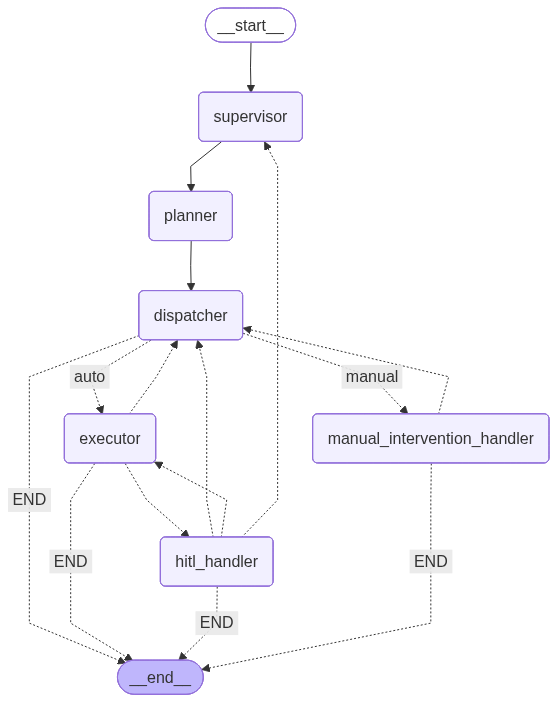

In [17]:
#  可视化
try:
    from IPython.display import Image
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Visualization skipped:", e)
    print(graph.get_graph().draw_mermaid())

In [21]:
import gradio as gr
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from typing import TypedDict
import uuid

MAX_BUTTONS = 4
# TODO：改变所有的logging到UI上,得实时刷新，不能过一个节点才给出来
# TODO：职责分离messages 和execution_log,现在的log全依赖控制台，可能需要一个新的logger给两边同时发送。现在Skill和Agent可能会产生两层不同的Logger，思考一下咋办。
# TODO：填充所有的command
# FIXME:日志打印出来是char list的形式，得改成字符串


def check_interrupt(config, session):
    state = graph.get_state(config)
    log_lines = state.values.get("execution_log", [])
    log = "\n".join(log_lines) + "\n"  # list → 字符串

    if state.next:
        interrupt_val = state.tasks[0].interrupts[0].value
        options = interrupt_val.get("options", [])
        description = interrupt_val.get("description", "")
        session["waiting"] = True
        log += f"[ 任务 ] {description}\n"
        log += "⏸ 等待人工确认...\n"
        return [log, session] + get_button_updates(options)

    session["waiting"] = False
    return [log, session] + hide_buttons()

def start_flow(prompt, session):
    thread_id = str(uuid.uuid4())
    session["thread_id"] = thread_id
    config = {"configurable": {"thread_id": thread_id}}

    context = RobotContext()
    
     # ------ init robodk
    registry = SkillRegistry.instance()
    print("[init] Skills registered:", registry.list_skills())
    context.debug_skip_check = True # IK和碰撞检查都没配置好，现在在模拟环境直接跳过。


    # 重置 supervisor 单例（确保使用已注册的 SkillRegistry）
    _supervisor_agent = None

    _initial_state: GlobalState = {
        "messages":            [HumanMessage(content=prompt)],
        "todo_list":           [],
        "current_task":        {},
        "robot_state":         {},
        "halt_flag":           False,
        "halt_reason":         None,
        "last_result":         None,
        "intervention_action": None,
        "hitl_command":        None,
        "execution_log":       [],
    }

    _config = {"configurable": {"thread_id": "e2e-test-1"}}

    print("\n=== Running end-to-end graph ===")
    graph.invoke(_initial_state, config=config)
    
    return check_interrupt(config, session)


def handle_choice(choice, session):
    if not session.get("waiting"):
        return ["", session] + hide_buttons()

    config = {"configurable": {"thread_id": session["thread_id"]}}
    graph.invoke(Command(resume=choice), config=config)
    return check_interrupt(config, session)















# --- 辅助 ---
def get_button_updates(options):
    updates = []
    for i in range(MAX_BUTTONS):
        if i < len(options):
            updates.append(gr.update(value=options[i], visible=True))
        else:
            updates.append(gr.update(visible=False))
    return updates

def hide_buttons():
    return [gr.update(visible=False)] * MAX_BUTTONS

# --- UI ---
with gr.Blocks(title="HITL Demo") as demo:

    session_state = gr.State({})

    log_box = gr.Textbox(
        label="运行日志",
        lines=15,
        interactive=False
    )

    with gr.Row():
        buttons = [gr.Button(visible=False) for _ in range(MAX_BUTTONS)]

    with gr.Row():
        prompt_box = gr.Textbox(
            placeholder="输入任务描述...",
            show_label=False,
            scale=4
        )
        start_btn = gr.Button("🚀 开始", variant="primary", scale=1)

    # outputs 顺序：log_box, session_state, btn0, btn1, btn2, btn3
    start_outputs = [log_box, session_state] + buttons
    decision_outputs = [log_box, session_state] + buttons

    start_btn.click(
        fn=start_flow,
        inputs=[prompt_box, session_state],
        outputs=start_outputs
    )

    prompt_box.submit(
        fn=start_flow,
        inputs=[prompt_box, session_state],
        outputs=start_outputs
    )

    for btn in buttons:
        btn.click(
            fn=handle_choice,
            inputs=[btn, session_state],
            outputs=decision_outputs
        )

demo.launch()

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.


[init] Skills registered: ['DummySkill', 'PickAndPlace']

=== Running end-to-end graph ===
[planner] Building plan via tool calls...
[planner] Done: 2 tasks (1 manual)
[dispatcher] Dispatching t1 (manual): 请人工检查以下完整任务计划后再继续执行：
- 技能：PickAndPlace
- 工件：Part_A_1
- 拾取接近点：App Pick Part A
- 拾取点：Pick Part A
- 放置接近点：App Place Part A 
- 放置点：Place Part A
- 工具：Gripper Extension
确认场景中工件位置、夹爪状态及路径无误后，方可继续。
[manual_handler] Handling manual task: 请人工检查以下完整任务计划后再继续执行：
- 技能：PickAndPlace
- 工件：Part_A_1
- 拾取接近点：App Pick Part A
- 拾取点：Pick Part A
- 放置接近点：App Place Part A 
- 放置点：Place Part A
- 工具：Gripper Extension
确认场景中工件位置、夹爪状态及路径无误后，方可继续。


2026-03-26 17:11:43,422 [INFO] SkiLib.skills.pick_and_place — Step 1/8: MoveL to pick_approach 'App Pick Part A'...


[manual_handler] Handling manual task: 请人工检查以下完整任务计划后再继续执行：
- 技能：PickAndPlace
- 工件：Part_A_1
- 拾取接近点：App Pick Part A
- 拾取点：Pick Part A
- 放置接近点：App Place Part A 
- 放置点：Place Part A
- 工具：Gripper Extension
确认场景中工件位置、夹爪状态及路径无误后，方可继续。
[dispatcher] Dispatching t2 (auto): PickAndPlace
[executor] Running: PickAndPlace({'item': 'Part_A_1', 'pick_approach': 'App Pick Part A', 'pick_target': 'Pick Part A', 'place_approach': 'App Place Part A ', 'place_target': 'Place Part A', 'transit_motion': 'MoveL', 'initial_motion': 'MoveL'})


2026-03-26 17:11:44,128 [INFO] SkiLib.skills.pick_and_place — Step 2/8: MoveL to pick_target 'Pick Part A'...
2026-03-26 17:11:44,617 [INFO] SkiLib.skills.pick_and_place — Step 3/8: Grasp 'Part_A_1'...
2026-03-26 17:11:44,802 [INFO] SkiLib.primitives.gripper — Grasp: intended='Part_A_1', attached='Part_A_1' via tool 'Gripper Extension'.
2026-03-26 17:11:44,804 [INFO] SkiLib.skills.pick_and_place — Step 4/8: MoveL depart to pick_approach 'App Pick Part A'...
2026-03-26 17:11:45,301 [INFO] SkiLib.skills.pick_and_place — Step 5/8: MoveL transit to place_approach 'App Place Part A '...
2026-03-26 17:11:46,025 [INFO] SkiLib.skills.pick_and_place — Step 6/8: MoveL to place_target 'Place Part A'...
2026-03-26 17:11:46,634 [INFO] SkiLib.skills.pick_and_place — Step 7/8: Release 'Part_A_1'...
2026-03-26 17:11:46,792 [INFO] SkiLib.primitives.gripper — Release: detached all objects from tool 'Gripper Extension' (expected item: 'Part_A_1').
2026-03-26 17:11:46,955 [INFO] SkiLib.skills.pick_and_pla

[dispatcher] No tasks in todo_list
[init] Skills registered: ['DummySkill', 'PickAndPlace']

=== Running end-to-end graph ===
[planner] Building plan via tool calls...
[planner] Done: 2 tasks (1 manual)
[dispatcher] Dispatching t1 (manual): 请人工检查以下完整计划后再继续执行：
1. 【PickAndPlace】将 Part_A_1 从拾取点 "Pick Part A" 移动到放置目标 "Place Part A"。
   - 拾取接近点：App Pick Part A
   - 拾取点：Pick Part A
   - 放置接近点：App Place Part A（注意名称末尾含空格）
   - 放置点：Place Part A
   - 操作对象：Part_A_1（场景中存在 Part_A_1 和 Part_A_2，默认使用 Part_A_1，如需更换请在此步骤终止并告知）

确认无误后，请放行继续执行。
[manual_handler] Handling manual task: 请人工检查以下完整计划后再继续执行：
1. 【PickAndPlace】将 Part_A_1 从拾取点 "Pick Part A" 移动到放置目标 "Place Part A"。
   - 拾取接近点：App Pick Part A
   - 拾取点：Pick Part A
   - 放置接近点：App Place Part A（注意名称末尾含空格）
   - 放置点：Place Part A
   - 操作对象：Part_A_1（场景中存在 Part_A_1 和 Part_A_2，默认使用 Part_A_1，如需更换请在此步骤终止并告知）

确认无误后，请放行继续执行。


In [15]:
# ── 端到端运行 ────────────────────────────────────────────────────────────────
from SkiLib.robotcontext import RobotContext
from SkiLib.registry import SkillRegistry

# 初始化 RobotContext（同时触发 SkillRegistry 自动扫描注册）
context = RobotContext()
registry = SkillRegistry.instance()
print("[init] Skills registered:", registry.list_skills())
context.debug_skip_check = True # IK和碰撞检查都没配置好，现在在模拟环境直接跳过。

# 重置 supervisor 单例（确保使用已注册的 SkillRegistry）
_supervisor_agent = None

_initial_state: GlobalState = {
    "messages":            [HumanMessage(content="把 Part_A_1 放到 目标点,然后把B_1放上去。人工上好螺丝帮你翻转之后把partC放上去。工件已配置完毕，可以直接执行自动任务。")],
    "todo_list":           [],
    "current_task":        {},
    "robot_state":         {},
    "halt_flag":           False,
    "halt_reason":         None,
    "last_result":         None,
    "intervention_action": None,
    "hitl_command":        None,
    "execution_log":       [],
}

_config = {"configurable": {"thread_id": "e2e-test-1"}}

print("\n=== Running end-to-end graph ===")
_final = graph.invoke(_initial_state, config=_config)

print("\n=== execution_log ===")
for line in _final.get("execution_log", []):
    print(" ", line)

print("\n=== todo_list remaining ===", _final.get("todo_list"))
print("=== current_task ===",         _final.get("current_task"))
print("=== halt_flag ===",            _final.get("halt_flag"))


[init] Skills registered: ['DummySkill', 'PickAndPlace']

=== Running end-to-end graph ===
[supervisor] Agent built. Skills: ['DummySkill', 'PickAndPlace']
[planner] Building plan via tool calls...


2026-03-26 15:35:07,969 [INFO] SkiLib.skills.pick_and_place — Step 1/8: MoveL to pick_approach 'App Pick Part A'...


[planner] Done: 4 tasks (1 manual)
[dispatcher] Dispatching t1 (auto): PickAndPlace
[executor] Running: PickAndPlace({'item': 'Part_A_1', 'pick_approach': 'App Pick Part A', 'pick_target': 'Pick Part A', 'place_approach': 'App Place Part A ', 'place_target': 'Place Part A', 'transit_motion': 'MoveL', 'initial_motion': 'MoveL'})


2026-03-26 15:35:08,861 [INFO] SkiLib.skills.pick_and_place — Step 2/8: MoveL to pick_target 'Pick Part A'...
2026-03-26 15:35:09,261 [INFO] SkiLib.skills.pick_and_place — Step 3/8: Grasp 'Part_A_1'...
2026-03-26 15:35:09,361 [INFO] SkiLib.primitives.gripper — Grasp: intended='Part_A_1', attached='Part_A_1' via tool 'Gripper Extension'.
2026-03-26 15:35:09,364 [INFO] SkiLib.skills.pick_and_place — Step 4/8: MoveL depart to pick_approach 'App Pick Part A'...
2026-03-26 15:35:09,767 [INFO] SkiLib.skills.pick_and_place — Step 5/8: MoveL transit to place_approach 'App Place Part A '...
2026-03-26 15:35:10,380 [INFO] SkiLib.skills.pick_and_place — Step 6/8: MoveL to place_target 'Place Part A'...
2026-03-26 15:35:10,840 [INFO] SkiLib.skills.pick_and_place — Step 7/8: Release 'Part_A_1'...
2026-03-26 15:35:10,892 [INFO] SkiLib.primitives.gripper — Release: detached all objects from tool 'Gripper Extension' (expected item: 'Part_A_1').
2026-03-26 15:35:10,941 [INFO] SkiLib.skills.pick_and_pla

[dispatcher] Dispatching t2 (auto): PickAndPlace
[executor] Running: PickAndPlace({'item': 'Part_B_1', 'pick_approach': 'App Pick Part B', 'pick_target': 'Pick Part B', 'place_approach': 'App Place Part B', 'place_target': 'Place Part B', 'transit_motion': 'MoveL', 'initial_motion': 'MoveL'})


2026-03-26 15:35:11,967 [INFO] SkiLib.skills.pick_and_place — Step 2/8: MoveL to pick_target 'Pick Part B'...
2026-03-26 15:35:12,517 [INFO] SkiLib.skills.pick_and_place — Step 3/8: Grasp 'Part_B_1'...
2026-03-26 15:35:12,618 [INFO] SkiLib.primitives.gripper — Grasp: intended='Part_B_1', attached='Part_B_1' via tool 'Gripper Extension'.
2026-03-26 15:35:12,620 [INFO] SkiLib.skills.pick_and_place — Step 4/8: MoveL depart to pick_approach 'App Pick Part B'...
2026-03-26 15:35:13,126 [INFO] SkiLib.skills.pick_and_place — Step 5/8: MoveL transit to place_approach 'App Place Part B'...
2026-03-26 15:35:13,816 [INFO] SkiLib.skills.pick_and_place — Step 6/8: MoveL to place_target 'Place Part B'...
2026-03-26 15:35:14,274 [INFO] SkiLib.skills.pick_and_place — Step 7/8: Release 'Part_B_1'...
2026-03-26 15:35:14,426 [INFO] SkiLib.primitives.gripper — Release: detached all objects from tool 'Gripper Extension' (expected item: 'Part_B_1').
2026-03-26 15:35:14,428 [INFO] SkiLib.skills.pick_and_plac

[dispatcher] Dispatching t3 (manual): 人工介入：请为 Part_A_1 + Part_B_1 组合体上好螺丝，然后将组合体翻转至指定方向，完成后确认继续。
[manual_handler] Handling manual task: 人工介入：请为 Part_A_1 + Part_B_1 组合体上好螺丝，然后将组合体翻转至指定方向，完成后确认继续。
[dispatcher] Dispatching t4 (auto): PickAndPlace
[executor] Running: PickAndPlace({'item': 'Part_C_1', 'pick_approach': 'App Pick Part C', 'pick_target': 'Pick Part C', 'place_approach': 'App Place Part C', 'place_target': 'Place Part C', 'transit_motion': 'MoveL', 'initial_motion': 'MoveL'})


2026-03-26 15:35:15,536 [INFO] SkiLib.skills.pick_and_place — Step 2/8: MoveL to pick_target 'Pick Part C'...
2026-03-26 15:35:16,090 [INFO] SkiLib.skills.pick_and_place — Step 3/8: Grasp 'Part_C_1'...
2026-03-26 15:35:16,188 [INFO] SkiLib.primitives.gripper — Grasp: intended='Part_C_1', attached='Part_C_1' via tool 'Gripper Extension'.
2026-03-26 15:35:16,190 [INFO] SkiLib.skills.pick_and_place — Step 4/8: MoveL depart to pick_approach 'App Pick Part C'...
2026-03-26 15:35:16,742 [INFO] SkiLib.skills.pick_and_place — Step 5/8: MoveL transit to place_approach 'App Place Part C'...
2026-03-26 15:35:17,442 [INFO] SkiLib.skills.pick_and_place — Step 6/8: MoveL to place_target 'Place Part C'...
2026-03-26 15:35:17,889 [INFO] SkiLib.skills.pick_and_place — Step 7/8: Release 'Part_C_1'...
2026-03-26 15:35:17,943 [INFO] SkiLib.primitives.gripper — Release: detached all objects from tool 'Gripper Extension' (expected item: 'Part_C_1').
2026-03-26 15:35:17,994 [INFO] SkiLib.skills.pick_and_plac

[dispatcher] No tasks in todo_list

=== execution_log ===
  [executor] t1 PickAndPlace -> SUCCESS
  [executor] t2 PickAndPlace -> SUCCESS
  [manual_handler] t3 -> COMPLETE (stub)
  [executor] t4 PickAndPlace -> SUCCESS

=== todo_list remaining === []
=== current_task === {}
=== halt_flag === False
